In [1]:
import numpy as np
import scipy.stats as sts
import matplotlib.pyplot as plt
import pandas as pd
import seaborn 
%matplotlib inline

# Гречишкин Денис ПМ-31: Лабораторная работа №8

# Часть 8.4. Примеры для совместного обсуждения

## пример 1

In [2]:
n1 = 50
n2 = 50
k1 = 21
k2 = 17
n = n1 + n2
v1 = ((k1 + k2)*n1)/(n1 + n2)
v2 = ((k1 + k2)*n2)/(n1 + n2)
v3 = ((n1 + n2 - k1 - k2)*n1)/(n1 + n2)
v4 = ((n1 + n2 - k1 - k2)*n1)/(n1 + n2)
print(min(v1, v2, v3, v4))

19.0


обе гипотезы применимы, применим 2-ю

In [3]:
Z_v2 = (n1 + n2)/(n1*n2*k1*k2)
p_value2 = 1 - sts.chi2(1).cdf(Z_v2)
print('Выборочное значение статистики', Z_v2)
print('p_value', p_value2)

Выборочное значение статистики 0.00011204481792717087
p_value 0.9915544519122131


Теперь по 1-му критерию

In [4]:
h = (k1 + k2)/(n1 + n2)
Z_v1 = (k1/n1 - k2/n2)/np.sqrt(h*(1 - h)*(1/n1 + 1/n2))
p_value = 1 - (sts.norm(0, 1)).cdf(Z_v1)
p_value1 = 2*min(p_value, 1-p_value)
print('Выборочное значение статистики', Z_v1)
print('p_value', p_value1)

Выборочное значение статистики 0.8240856434303288
p_value 0.4098908969616111


## пример 2

In [5]:
data_1_2_3 = pd.read_excel('Data_8.xlsx', header = 0)
d_1_2_3 = pd.DataFrame(data_1_2_3)
v_1_2_3 = d_1_2_3.astype(float)
print(v_1_2_3)

     Выборка 1  Выборка 2  Выборка 3
0    -6.040990   0.130944  -1.283196
1     3.694515   8.469794   7.570399
2     7.430343   3.254662   2.033345
3     4.123574  -0.587104  -2.045567
4    12.528761   0.056922  -1.361786
..         ...        ...        ...
145  14.926193 -10.136527 -12.184460
146  -1.465086  -1.169938  -2.664379
147   6.176122   5.874292   4.814680
148   2.313114   4.213634   3.051513
149  28.602220  11.497309  10.784797

[150 rows x 3 columns]


In [6]:
v_1 = v_1_2_3['Выборка 1'].dropna()
v_2 = v_1_2_3['Выборка 2'].dropna()
v_3 = v_1_2_3['Выборка 3'].dropna()

alpha = 0.05
s1 = np.var(v_1, ddof = 1)
s2 = np.var(v_2, ddof = 1)
s3 = np.var(v_3, ddof = 1)

# Часть 8.5. Задания для самостоятельного выполнения

## Задание 1: 
В файле «Данные 8_1» приведены данные успеваемости студентов 1-го курса по четырем математическим дисциплинам по 100 балльной шкале (нормированные к 1). Иван и Петр, входящие в число 
этих студентов, поспорили насчет того, по каким дисциплинам у их однокурсников хороших оценок больше, а по каким меньше. Иван думает, что в этом плане между дисциплинами особой разницы нет, а Петр 
настаивает, что есть.  Подумав, они решили, что для объективного разрешения спора им надо, опираясь на методы математической статистики, сопоставить вероятности получения не менее 𝑛 баллов в разных парах дисциплин (а именно, проверить гипотезы о равенстве вероятностей получения не менее 𝑛 баллов по этим дисциплинам (см. п. 5 подраздела 8.2)). Ваша задача – помочь Ивану и Петру, взяв на себя анализ пары дисциплин (в соответствии с вашим вариантом). Нужно найти диапазоны значений 𝑛, при которых на уровне значимости 𝛼, данные подтверждают мнение Ивана и диапазоны значений 𝑛, при которых на уровне значимости 𝛼, данные подтверждают мнение Петра. $\newline$
Замечание. Данные реальные и требуют предварительной обработки.  $\newline$
Вариант 1: ОМА и МА

## Решение: 
Импортируем данные. Так как в таблице не для всех клеток заполнены клетки, предварительно в таблице **вставим на место пустых клеток нули**.

In [7]:
#импортируем данные
DATA_1 = pd.read_excel('Data_8_1.xlsx', header = 0)
D_1 = pd.DataFrame(DATA_1)
#D_1 = D_1.replace('-', 0)
D_1 = D_1.astype(float)

**Возьмем уровень значимости $\alpha = 0.1$. $\newline$**
Пусть событие A = (У студента оценка по предмету - хорошая), $n_1$ - число испытаний в выборке с успеваемостью студентов по ОМА, $n_2$ - число испытаний в выборке с успеваемостью студентов по МА, событие А в серии из $n_1$ испытаний произошло $k_1$ раз, а в другой серии из $n_2$ испытаний произошло $k_2$ раза, $p_1 = \frac{k_1}{n_1}$, $p_2 = \frac{k_2}{n_2}$,  $\newline$
Основная гипотеза $H_0: p_1 = p_2$ $\newline$
Альтернативная гипотеза $H_1: p_1 \ne p_2$ $\newline$
Проверим достоверность гипотез сразу по двум критериям

РЕЗУЛЬТАТ ПРОВЕРКИ ПО 1-МУ КРИТЕРИЮ

значения баллов на которых прав Иван
[0.51 0.52 0.53 0.54 0.55 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64
 0.65]
значения баллов на которых прав Петр
[0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13 0.14
 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27 0.28
 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41 0.42
 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.66 0.67 0.68 0.69 0.7  0.71
 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83 0.84 0.85
 0.86 0.87]


РЕЗУЛЬТАТ ПРОВЕРКИ ПО 2-МУ КРИТЕРИЮ

значения баллов на которых прав Иван
[0.51 0.52 0.53 0.54 0.55 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64
 0.65]
значения баллов на которых прав Петр
[0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13 0.14
 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27 0.28
 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41 0.42
 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5 

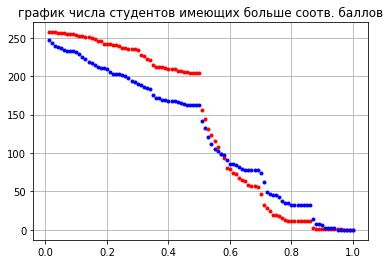

In [26]:
VIBORKA_OMA = D_1[' ОМА_итог'].dropna()
VIBORKA_MA = D_1[' МА_итог'].dropna()
SCORES = [0.01*i for i in range(1, 101)]
RESULT_KR1 = []
RESULT_KR2 = []
alpha = 0.1

for SCORE in SCORES:
    n1 = len(VIBORKA_OMA)
    n2 = len(VIBORKA_MA)
    k1 = 0
    k2 = 0
    for i in range(n1):
        if(VIBORKA_OMA[i] >= SCORE):
            k1 += 1
    for i in range(n2):
        if(VIBORKA_MA[i] >= SCORE):
            k2 += 1
    drob1 = ((k1 + k2)*n1)/(n1 + n2)
    drob2 = ((k1 + k2)*n2)/(n1 + n2)
    drob3 = ((n1 + n2 - k1 - k2)*n1)/(n1 + n2)
    drob4 = ((n1 + n2 - k1 - k2)*n2)/(n1 + n2)
    
    #исправления: сделаем дополнительно иллюстрацию 
    plt.plot(SCORE, k1, '.r')#на графике красным будут отмечены баллы по основам мат. анализа
    plt.plot(SCORE, k2, '.b')#синим - баллы по мат. анализу
    #проверка по 1 критерию
    if(min(drob1, drob2, drob3, drob4) > 5):
        h = (k1 + k2)/(n1 + n2)
        Z_VIB = (k1/n1 - k2/n2)/(np.sqrt(h*(1 - h)*(1/n1 + 1/n2)))
        P = (sts.norm(0,1)).cdf(Z_VIB)
        P_VALUE = 2*min(P, 1 - P)
        if(alpha > P_VALUE):
            RESULT_KR1.append('прав Петр')
        else:
            RESULT_KR1.append('прав Иван')
    else:
        RESULT_KR1.append('критерий не применим')
    
    
    #проверка по 2 критерию  
    if((min(drob1, drob2, drob3, drob4) > 5) and (n1 + n2 > 20)):
        Z_VIB = ((n1 + n2)*(k1*(n2 - k2) - k2*(n1 - k1))**2)/(n1 * n2 * (k1 + k2) * (n1 + n2 - k1 - k2))
        P_VALUE = 1 - (sts.chi2(1)).cdf(Z_VIB)
        if(alpha <= P_VALUE):
            RESULT_KR2.append('прав Иван')
        else:
            RESULT_KR2.append('прав Петр')
    else:
        RESULT_KR2.append('критерий не применим')
#создаем сетку на графике и добавляем заголовок
plt.grid(True)
plt.title('график числа студентов имеющих больше соотв. баллов')


#исправление: отформатируем вывод
IVAN_S_ZNACHS_KR1 = []
PETR_S_ZNACHS_KR1 = []
IVAN_S_ZNACHS_KR2 = []
PETR_S_ZNACHS_KR2 = []

for i in range(len(SCORES)):
    if(RESULT_KR1[i] == 'прав Иван'):
        IVAN_S_ZNACHS_KR1.append(SCORES[i])
    else:
        if(RESULT_KR1[i] == 'прав Петр'):
            PETR_S_ZNACHS_KR1.append(SCORES[i])
        
    if(RESULT_KR2[i] == 'прав Иван'):
        IVAN_S_ZNACHS_KR2.append(SCORES[i])
    else:
        if (RESULT_KR2[i] == 'прав Петр'):
            PETR_S_ZNACHS_KR2.append(SCORES[i])


print("РЕЗУЛЬТАТ ПРОВЕРКИ ПО 1-МУ КРИТЕРИЮ\n")
print('значения баллов на которых прав Иван')
print(np.round(IVAN_S_ZNACHS_KR1, 2))
print('значения баллов на которых прав Петр')
print(np.round(PETR_S_ZNACHS_KR1, 2))
print('\n')

print("РЕЗУЛЬТАТ ПРОВЕРКИ ПО 2-МУ КРИТЕРИЮ\n")
print('значения баллов на которых прав Иван')
print(np.round(IVAN_S_ZNACHS_KR2, 2))
print('значения баллов на которых прав Петр')
print(np.round(PETR_S_ZNACHS_KR2, 2))

Видно что результаты обоих критериев одинаковы и сходятся с диаграммой.

$\newline$

## Задание 2: 
Сгенерируйте две выборки (A и B) различных объемов из нормально распределенных генеральных совокупностей с параметрами,
$m_A$ $\sigma_A$ и, $m_B$ $\sigma_B$ (возьмите значения $m_A$ и $m_B$ близкими, но не равными, а $\sigma_A$ $\sigma_B$ выберите такими, чтобы близки (но не равны) были их квадраты). Проверьте гипотезу о равенстве дисперсий по критерию Фишера (см. п. 2 подраздела 8.2) на уровне значимости 0,05. 
Сформулируйте выводы.  
Если гипотеза подтвердится, то сгенерируйте две другие выборки (C и D), для которых гипотеза отклонится (при необходимости поварьируйте параметры, поэкспериментируйте, чтобы добиться заданного результата).  
Если гипотеза о равенстве дисперсий выборок A и B будет отклонена, то сгенерируйте две другие выборки (C' и D'), для которых 
гипотеза подтвердится (при необходимости поварьируйте параметры, 
поэкспериментируйте, чтобы добиться заданного результата).  

## Решение: 
Возьмем $m_A = 2.5; m_B = 2.4; \sigma_A = 5; \sigma_A = 2\sqrt{5}$; объем выборки А и B  $n_A = 100; n_B = 150$; уровень значимости $\alpha = 0.05$ (по условию).

Основная гипотеза $H_0: \sigma_A = \sigma_B$ $\newline$
Альтернативная гипотеза $H_1: \sigma_A \ne \sigma_B$

In [9]:
m_a = 2.5
m_b = 2.4
sigma_a = 5
sigma_b = 2*np.sqrt(5)
n_a = 100
n_b = 150
alpha = 0.05
VIBORKA_A = np.random.normal(m_a, sigma_a, n_a)
VIBORKA_B = np.random.normal(m_b, sigma_b, n_b)
S_1 = np.var(VIBORKA_A, ddof = 1)
S_2 = np.var(VIBORKA_B, ddof = 1)
print("S_1^2", S_1)
print("S_2^2", S_2)
F_VIB = S_1/S_2
F_EDGE = (sts.f(n_a - 1, n_b - 1)).ppf(1 - alpha/2)
if(F_VIB > F_EDGE):
    print("Основная гипотеза отвергается, альтернативная гипотеза принимается")
else:
    print("Основная гипотеза принимается")

S_1^2 25.45398749865268
S_2^2 20.836238976681653
Основная гипотеза принимается


Сформируем выборки C' и D': $m_{C'} = 2.5; m_{D'} = 2.55; \sigma_{C'} = \sqrt{10}; \sigma_{D'} = 3$ объем выборки C' и D' $n_{C'} = 1000; n_{C'} = 1500$ соответственно; уровень значимости остается тем-же. $\newline$
Основная гипотеза: $H_0: \sigma_{C'} = \sigma_{D'}$ $\newline$
Альтернативная гипотеза: $H_1: \sigma_{C'} \ne \sigma_{D'}$ 

In [10]:
m_c = 2.5
m_d = 2.55
sigma_c = np.sqrt(10)
sigma_d = 3
n_c = 1000
n_d = 1500
alpha = 0.05
VIBORKA_C = np.random.normal(m_a, sigma_a, n_a)
VIBORKA_D = np.random.normal(m_b, sigma_b, n_b)
S_1 = np.var(VIBORKA_C, ddof = 1)
S_2 = np.var(VIBORKA_D, ddof = 1)
print("S_1^2", S_1)
print("S_2^2", S_2)
F_VIB = S_1/S_2
F_EDGE = (sts.f(n_c - 1, n_d - 1)).ppf(1 - alpha/2)
if(F_VIB > F_EDGE):
    print("Основная гипотеза отвергается, альтернативная гипотеза принимается")
else:
    print("Основная гипотеза принимается")

S_1^2 26.04394882240481
S_2^2 20.16504116133721
Основная гипотеза отвергается, альтернативная гипотеза принимается


$\newline$

## Задание 3: Для выполнения задания используйте пару выборок, смоделированных при выполнении задания 2, для которой гипотеза о 
равенстве дисперсий подтвердилась. Проверьте гипотезу о равенстве математических ожиданий. Укажите диапазон значений $\alpha$, при которых гипотеза принимается. 

## Решение: Гипотезу о равенстве мат ожиданий будем проверять для выборок C' и D'. $\newline$
Основная гипотеза: $H_0: m_{C'} = m_{D'}$ $\newline$
Альтернативная гипотеза: $H_1: m_{C'} \ne m_{D'}$ $\newline$

In [11]:
S_1 = np.var(VIBORKA_C, ddof = 1)
S_2 = np.var(VIBORKA_D, ddof = 1)
M_VIB_C = np.sum(VIBORKA_C)/n_c
M_VIB_D = np.sum(VIBORKA_D)/n_d
T_VIB = (M_VIB_C - M_VIB_D)/(np.sqrt((((n_c - 1)*S_1 + (n_d - 1)*S_2)/\
                                      (n_c + n_d - 2))*(1/n_c + 1/n_d)))
P = (sts.t(n_c + n_d - 2)).cdf(T_VIB)
P_VALUE = 2*min(P, 1 - P)
print("Выборочное значение статистики T:", T_VIB)
print("При alpha >", P_VALUE, "основная гипотеза принимается")
print("При alpha <=", P_VALUE, "основная гипотеза отклоняется")

Выборочное значение статистики T: 0.24102341986099676
При alpha > 0.809556745399298 основная гипотеза принимается
При alpha <= 0.809556745399298 основная гипотеза отклоняется


$\newline$

## Задание 4: 
Для выполнения этого задания используйте пару выборок, смоделированных при выполнении задания 2, для которой гипотеза 
о равенстве дисперсий была отклонена. Проверьте гипотезу о равенстве математических ожиданий. Укажите диапазон значений $\alpha$, при которых гипотеза принимается.  

## Решение: 
Гипотезу о равенстве мат ожиданий будем проверять для выборок A и B. $\newline$
Основная гипотеза: $H_0: m_{A} = m_{B}$ $\newline$
Альтернативная гипотеза: $H_1: m_{A} \ne m_{B}$ $\newline$

In [12]:
S_1_2 = np.var(VIBORKA_A, ddof = 1)
S_2_2 = np.var(VIBORKA_B, ddof = 1)
M_VIB_A = np.sum(VIBORKA_A)/n_a
M_VIB_B = np.sum(VIBORKA_B)/n_b
T_VIB_2 = (M_VIB_A - M_VIB_B)/(np.sqrt(S_1/n_a + S_1/n_b))
k = np.round((((S_1_2/n_a + S_2_2/n_b)**2)/(((S_1_2/n_a)**2)/(n_a - 1) + \
                                            ((S_2_2/n_b)**2)/(n_b - 1))), 0)
P = (sts.t(k)).cdf(T_VIB_2)
P_VALUE_2 = 2*min(P, 1 - P)
print("Выборочное значение статистики T:", T_VIB_2)
print("При alpha <=", P_VALUE_2, "основная гипотеза отклоняется")
print("При alpha >", P_VALUE_2, "основная гипотеза принимается")

Выборочное значение статистики T: -1.0230628498879777
При alpha <= 0.30753278014515384 основная гипотеза отклоняется
При alpha > 0.30753278014515384 основная гипотеза принимается
